In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

# all the plots get saved in here, so make the folder if it doesn't exist yet
os.makedirs("plots_gates", exist_ok=True)

# bold titles/labels on everything, just looks a bit more "finished"
plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["axes.titleweight"] = "bold"

LR = 0.1
EPOCHS = 50

In [ ]:
def step(x):
    return 1 if x >= 0 else 0


def train(X, y, lr=LR, epochs=EPOCHS):

    n, d = X.shape
    w = np.zeros(d)
    b = 0.0

    hist = []
    cnt = 0
    for ep in range(epochs):
        bad = False

        for i in range(n):
            xi = X[i]
            t = y[i]

            z = np.dot(xi, w) + b
            p = step(z)
            e = t - p

            if e != 0:
                w = w + lr * e * xi
                b = b + lr * e

                cnt += 1
                hist.append((w.copy(), b))
                bad = True

                print(f"  Update #{cnt}: sample {xi}, target={t}, "
                      f"pred={p} -> weights={w}, bias={b:.2f}")

        if not bad:
            print(f"  converged after {ep + 1} epoch(s), {cnt} total updates.\n")
            break

    return hist

In [10]:
def plot_gate(X, y, hist, name, fname):

    d = X.shape[1]
    nu = len(hist)
    cols = 3
    rows = int(np.ceil(nu / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(4.5 * cols, (4 if d == 2 else 3.5) * rows))
    axes = np.array(axes).reshape(-1)

    for idx, (w, b) in enumerate(hist):
        ax = axes[idx]

        for pt, lb in zip(X, y):
            c = "tab:blue" if lb == 1 else "tab:red"
            mk = "o" if lb == 1 else "x"
            x2 = pt[1] if d == 2 else 0
            ax.scatter(pt[0], x2, c=c, marker=mk, s=150, zorder=3)
            
        if d == 2:
            if abs(w[1]) > 1e-6:
                xv = np.linspace(-0.5, 1.5, 100)
                ax.plot(xv, -(w[0] * xv + b) / w[1], color="black", linestyle="-", linewidth=2)
            elif abs(w[0]) > 1e-6:
                ax.axvline(-b / w[0], color="black", linestyle="-", linewidth=2)
            ax.set_xlim(-0.5, 1.5)
            ax.set_ylim(-0.5, 1.5)
            ax.set_xlabel("x1")
            ax.set_ylabel("x2")
        else:
            if abs(w[0]) > 1e-6:
                ax.axvline(-b / w[0], color="black", linestyle="-", linewidth=2)
            ax.set_xlim(-1, 2)
            ax.set_ylim(-1, 1)
            ax.set_yticks([])
            ax.set_xlabel("x")

        ax.set_title(f"Update {idx + 1}\nw={np.round(w, 2)}, b={b:.2f}", fontsize=10)
        ax.grid(alpha=0.3)

    # any leftover subplot slots (grid doesn't divide evenly) just get hidden
    for j in range(nu, len(axes)):
        axes[j].axis("off")

    fig.suptitle(f"{name} Gate - Decision Boundary After Each Weight Update", fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    fig.savefig(fname, dpi=300, bbox_inches="tight")
    plt.show()

In [11]:
# ---------- AND gate ----------
print("Training AND gate...")
Xa = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
ya = np.array([0, 0, 0, 1])

ha = train(Xa, ya)

Training AND gate...
  Update #1: sample [0 0], target=0, pred=1 -> weights=[0. 0.], bias=-0.10
  Update #2: sample [1 1], target=1, pred=0 -> weights=[0.1 0.1], bias=0.00
  Update #3: sample [0 0], target=0, pred=1 -> weights=[0.1 0.1], bias=-0.10
  Update #4: sample [0 1], target=0, pred=1 -> weights=[0.1 0. ], bias=-0.20
  Update #5: sample [1 1], target=1, pred=0 -> weights=[0.2 0.1], bias=-0.10
  Update #6: sample [0 1], target=0, pred=1 -> weights=[0.2 0. ], bias=-0.20
  Update #7: sample [1 0], target=0, pred=1 -> weights=[0.1 0. ], bias=-0.30
  Update #8: sample [1 1], target=1, pred=0 -> weights=[0.2 0.1], bias=-0.20
  converged after 4 epoch(s), 8 total updates.



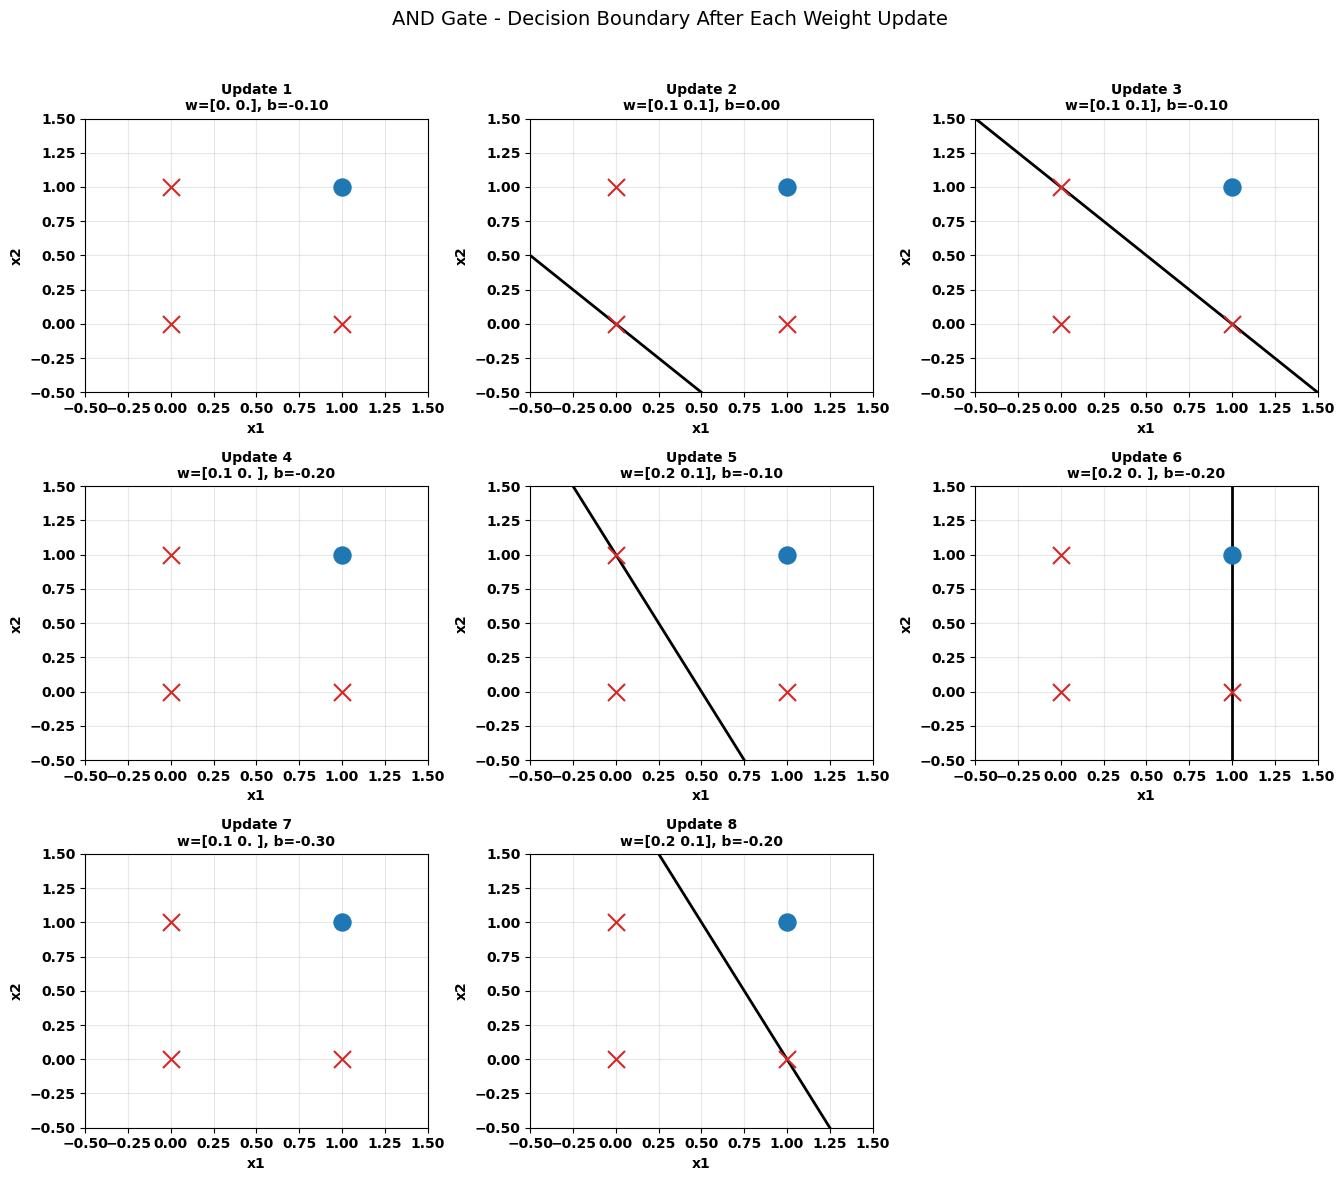

In [12]:
plot_gate(Xa, ya, ha, "AND", "plots_gates/AND_gate_perceptron.png")

In [13]:
# ---------- OR gate ----------
print("Training OR gate...")
Xo = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
yo = np.array([0, 1, 1, 1])

ho = train(Xo, yo)

Training OR gate...
  Update #1: sample [0 0], target=0, pred=1 -> weights=[0. 0.], bias=-0.10
  Update #2: sample [0 1], target=1, pred=0 -> weights=[0.  0.1], bias=0.00
  Update #3: sample [0 0], target=0, pred=1 -> weights=[0.  0.1], bias=-0.10
  Update #4: sample [1 0], target=1, pred=0 -> weights=[0.1 0.1], bias=0.00
  Update #5: sample [0 0], target=0, pred=1 -> weights=[0.1 0.1], bias=-0.10
  converged after 4 epoch(s), 5 total updates.



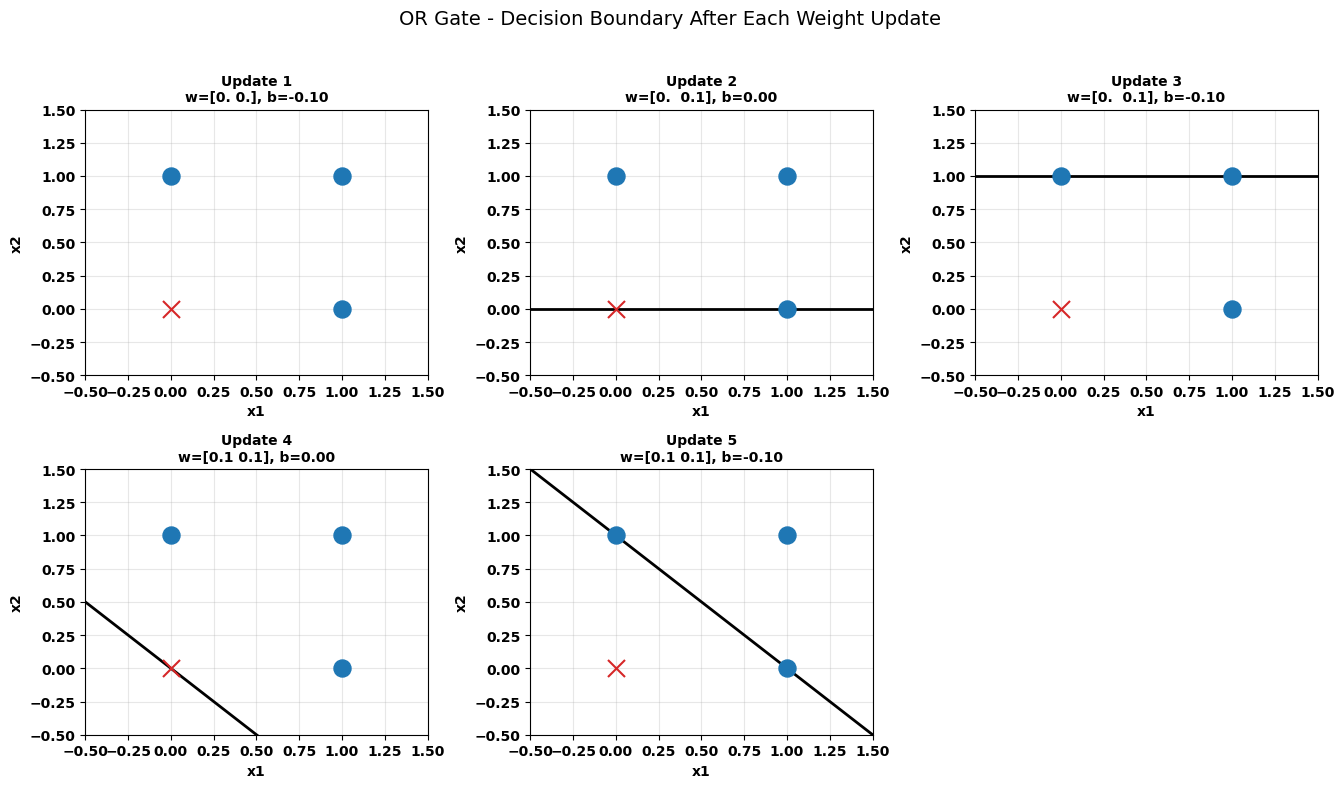

In [14]:
plot_gate(Xo, yo, ho, "OR", "plots_gates/OR_gate_perceptron.png")

In [15]:
# ---------- NOT gate ----------
print("Training NOT gate...")
Xn = np.array([[0], [1]])
yn = np.array([1, 0])

hn = train(Xn, yn)

Training NOT gate...
  Update #1: sample [1], target=0, pred=1 -> weights=[-0.1], bias=-0.10
  Update #2: sample [0], target=1, pred=0 -> weights=[-0.1], bias=0.00
  converged after 3 epoch(s), 2 total updates.



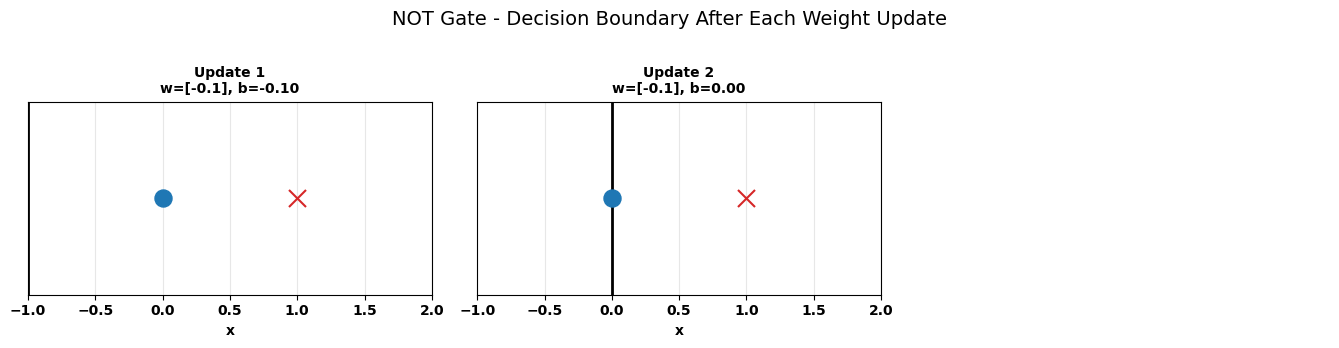

done! all 3 plots saved in the plots_gates/ folder.


In [16]:
plot_gate(Xn, yn, hn, "NOT", "plots_gates/NOT_gate_perceptron.png")

print("done! all 3 plots saved in the plots_gates/ folder.")